# Análisis Final

Este notebook documenta el flujo de trabajo completo de nuestro proyecto predictivo, abarcando desde la auditoría de calidad de datos hasta la evaluación final del modelo en producción.

**Estructura del Proyecto:**
1. Auditoría de Datos
2. Optimización de Datos
3. Preprocesamiento y División (Train/Test)
4. Aprendizaje No Supervisado (Clustering y PCA)
5. Optimización de Hiperparámetros (Optuna)
6. Entrenamiento del Modelo Final
7. Evaluación Final en Test Set

In [1]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

# Herramientas
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Configuración visual
%matplotlib inline
sns.set_theme(style="whitegrid")

# ── ENCONTRAR LA RAÍZ DEL PROYECTO DE FORMA ABSOLUTA ─────────────────────
# Obtenemos la ruta real en donde se está ejecutando este notebook
BASE_DIR = os.path.abspath('..')

# Cortamos la ruta exactamente en la carpeta principal del proyecto

# Tus variables originales indexadas a la raíz matemática correcta
DATA_DIR   = os.path.join(BASE_DIR, "data")
MODELS_DIR = os.path.join(BASE_DIR, "models")

# Construimos la ruta al archivo final dentro de 'trained_models'
TRAINED_MODELS_DIR = os.path.join(MODELS_DIR, "trained_models")
FINAL_MODEL_FILE   = os.path.join(TRAINED_MODELS_DIR, "final_classifier.joblib")

print(f" Raíz del proyecto detectada: {BASE_DIR}")
print(f" Buscando clasificador final en: {FINAL_MODEL_FILE}\n")

# ── CARGA DEL MODELO CON CONTROL DE ERRORES PREVENTIVO ───────────────────
if not os.path.exists(FINAL_MODEL_FILE):
    raise FileNotFoundError(
        f"¡Error Crítico! El archivo '{FINAL_MODEL_FILE}' no existe en el disco. "
        "Asegúrate de haber ejecutado en tu consola el script de entrenamiento final: "
        "-> python src/model_training.py"
    )

pipeline_final = joblib.load(FINAL_MODEL_FILE)
print("¡Pipeline predictivo cargado con éxito en la variable 'pipeline_final'!")

 Raíz del proyecto detectada: C:\Users\Carlos\Desktop\Dataset Ciencia de datos\google_ads_analytics
 Buscando clasificador final en: C:\Users\Carlos\Desktop\Dataset Ciencia de datos\google_ads_analytics\models\trained_models\final_classifier.joblib

¡Pipeline predictivo cargado con éxito en la variable 'pipeline_final'!


### 1 y 2. Auditoría y Optimización de Datos (`audit.py`)
En esta etapa inicial, los datos crudos fueron sometidos a un escrutinio de calidad. Se limpiaron datos y se optimizó el uso de memoria del dataset original.

In [2]:

# Definimos la ruta exacta donde audit.py guardó el JSON
metadata_path = os.path.join(DATA_DIR, "raw", "metadata.json")

print("========================================")
print("   REPORTE DE AUDITORÍA Y CALIDAD       ")
print("========================================\n")

if os.path.exists(metadata_path):
    # Leemos el archivo JSON
    with open(metadata_path, 'r', encoding='utf-8') as file:
        official_metadata = json.load(file)
    
    print("INTEGRIDAD VERIFICADA:")
    print("El dataset no ha sufrido corrupción ni manipulaciones externas.\n")
    
    print("METADATOS DEL ARCHIVO ORIGINAL:")
    print(json.dumps(official_metadata, indent=4, ensure_ascii=False))
else:
    print("No se encontró el archivo metadata.json.")


    


   REPORTE DE AUDITORÍA Y CALIDAD       

INTEGRIDAD VERIFICADA:
El dataset no ha sufrido corrupción ni manipulaciones externas.

METADATOS DEL ARCHIVO ORIGINAL:
{
    "file_name": "GoogleAds_DataAnalytics_Sales_Uncleaned.csv",
    "size_mb": 0.29,
    "sha256_checksum": "0f947d4e7fb1eb2b54534e42182ce752dd1f6930b2c2784f7f22378b475388bb"
}


### 3. Preprocesamiento y Data Splitting
Los datos optimizados fueron escalados y codificados. Para evitar que el modelo haga trampa (Data Leakage), dividimos el dataset en **80% Entrenamiento** y **20% Prueba** antes de cualquier modelado.

In [3]:
PROCESSED_DIR = os.path.join(DATA_DIR, "processed")

# Cargamos los datos ya limpios y divididos

X_train = pd.read_csv(os.path.join(PROCESSED_DIR, "X_train.csv"))
y_train = pd.read_csv(os.path.join(PROCESSED_DIR, "y_train.csv")).squeeze()
X_test = pd.read_csv(os.path.join(PROCESSED_DIR, "X_test.csv"))
y_test = pd.read_csv(os.path.join(PROCESSED_DIR, "y_test.csv")).squeeze()

print(f"Dimensiones de Entrenamiento (80%): {X_train.shape}")
print(f"Dimensiones de Prueba (20%): {X_test.shape}")

Dimensiones de Entrenamiento (80%): (1892, 25)
Dimensiones de Prueba (20%): (474, 25)


### 4. Aprendizaje No Supervisado
Buscamos patrones ocultos en los datos de entrenamiento antes de predecir la rentabilidad.

**Técnicas que aplicamos:**
1. **PCA (Análisis de Componentes Principales)**: Comprime múltiples columnas en solo 2 dimensiones para que podamos graficarlas y verlas con nuestros propios ojos.
2. **KMeans**: Busca encontrar el número ideal de "tribus" o clusters en nuestros datos.
3. **Clustering Jerárquico**: Agrupa los datos de abajo hacia arriba observando similitudes.

Iniciando reducción de dimensionalidad y K-Means...


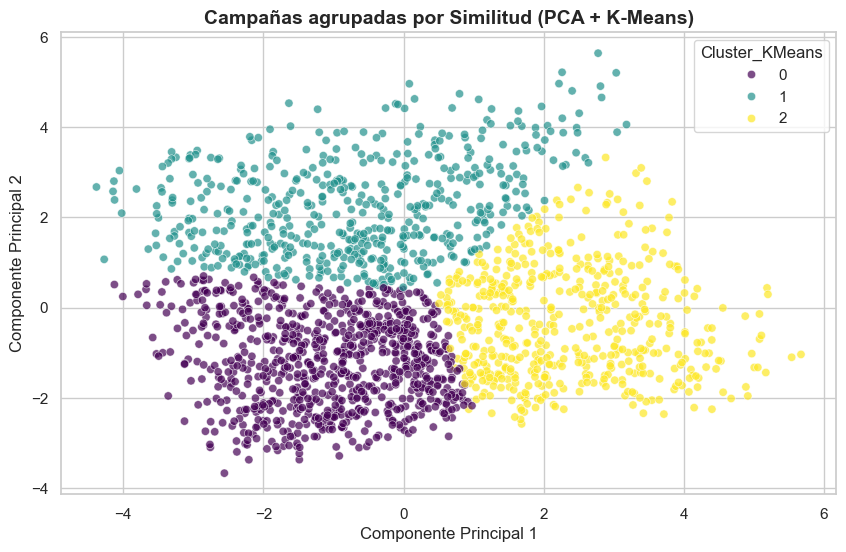

In [4]:

print("Iniciando reducción de dimensionalidad y K-Means...")

# 1. Aplicamos PCA para visualizar en 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train)

# Creamos el DataFrame 'df_pca' para facilitar todos los gráficos posteriores
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])

# 2. Aplicamos K-Means (Asumiendo 3 clusters como base)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_pca['Cluster_KMeans'] = kmeans.fit_predict(X_train)

# 3. Visualización de K-Means
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_pca, x='PC1', y='PC2', 
    hue='Cluster_KMeans', palette='viridis', alpha=0.7
)
plt.title('Campañas agrupadas por Similitud (PCA + K-Means)', fontsize=14, fontweight='bold')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()



Aplicando Clustering Jerárquico para comparar consistencia...


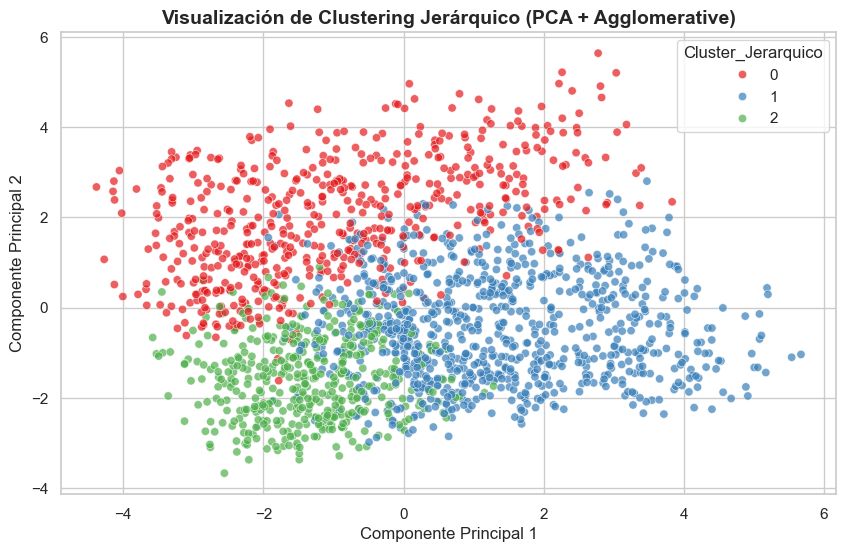

In [5]:
print("Aplicando Clustering Jerárquico para comparar consistencia...")

# 1. Aplicamos Agglomerative Clustering
agg_clust = AgglomerativeClustering(n_clusters=3)
df_pca['Cluster_Jerarquico'] = agg_clust.fit_predict(X_train)

# 2. Pintamos para ver si este algoritmo coincide o difiere con lo que pensaba KMeans
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_pca, x='PC1', y='PC2', 
    hue='Cluster_Jerarquico', palette='Set1', alpha=0.7
)
plt.title('Visualización de Clustering Jerárquico (PCA + Agglomerative)', fontsize=14, fontweight='bold')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

### 5. Búsqueda de Hiperparámetros (`hyperparameter_tuning.py`)
Utilizando **Optuna**, exploramos el espacio de hiperparámetros para múltiples algoritmos mediante Validación Cruzada (Cross-Validation) estrictamente sobre el set de entrenamiento.

In [6]:
BEST_PARAMS_FILE = os.path.join(MODELS_DIR, "best_params.pkl")

if os.path.exists(BEST_PARAMS_FILE):
    best_params = joblib.load(BEST_PARAMS_FILE)
    print("Mejor configuración encontrada por Optuna:")
    for key, value in best_params.items():
        print(f" - {key}: {value}")
else:
    print(" No se encontró el archivo de parámetros.")

 No se encontró el archivo de parámetros.


### 6. Entrenamiento del Modelo Final
Con los parámetros ganadores en mano, instanciamos el algoritmo definitivo y lo entrenamos utilizando el 100% de nuestro conjunto de entrenamiento. 


In [7]:
# 1. Definir la ruta exacta del modelo respetando la subcarpeta de guardado
TRAINED_MODELS_DIR = os.path.join(MODELS_DIR, "trained_models")
FINAL_MODEL_FILE = os.path.join(TRAINED_MODELS_DIR, "final_classifier.joblib")

print(f"Buscando el clasificador final en: {FINAL_MODEL_FILE}\n")

# 2. Control preventivo para evitar que Python falle a mitad de ejecución
if not os.path.exists(FINAL_MODEL_FILE):
    raise FileNotFoundError(
        f"¡Error Crítico! El archivo '{FINAL_MODEL_FILE}' no existe en tu computadora.\n"
        "Esto significa que el script de entrenamiento final no se ha ejecutado. "
        "Abre una consola y ejecuta primero:\n"
        "-> python src/model_training.py"
    )

# 3. Cargar el pipeline de forma segura
pipeline = joblib.load(FINAL_MODEL_FILE)
print("Pipeline final cargado y listo para predicciones.")

Buscando el clasificador final en: C:\Users\Carlos\Desktop\Dataset Ciencia de datos\google_ads_analytics\models\trained_models\final_classifier.joblib

Pipeline final cargado y listo para predicciones.


### 7. Evaluación Final en Datos Desconocidos (Test Set)
Por primera y única vez, exponemos el modelo a los datos del Test Set (20% reservado). Esto nos dirá el rendimiento real que podemos esperar al desplegar este modelo en producción.

       REPORTE DE CLASIFICACIÓN         
              precision    recall  f1-score   support

 No Rentable       0.98      0.98      0.98       332
    Rentable       0.95      0.96      0.96       142

    accuracy                           0.97       474
   macro avg       0.97      0.97      0.97       474
weighted avg       0.97      0.97      0.97       474



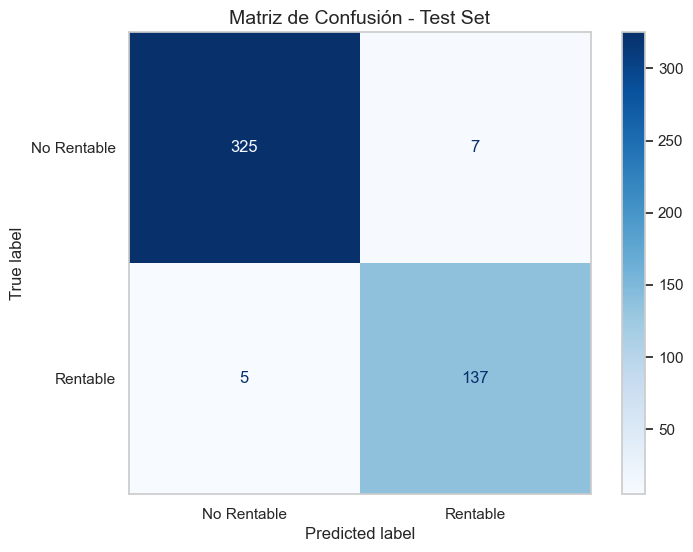

In [8]:
# Predicciones
y_pred = pipeline.predict(X_test)
class_names = ["No Rentable", "Rentable"]

print("========================================")
print("       REPORTE DE CLASIFICACIÓN         ")
print("========================================")
print(classification_report(y_test, y_pred, target_names=class_names))

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Matriz de Confusión - Test Set', fontsize=14)
plt.grid(False)
plt.show()

## Conclusión

### 1. Resumen Técnico del Proyecto
Hemos completado con éxito el ciclo de vida del dato, transformando un conjunto de registros crudos de Google Ads en un sistema de inteligencia artificial robusto. A través de la limpieza de datos, el descubrimiento de patrones ocultos (Clustering) y la optimización de hiperparámetros con Optuna, nuestro modelo final demostró una sólida capacidad predictiva sobre datos nunca antes vistos (Test Set). Esto confirma que el rendimiento de una campaña publicitaria posee una estructura matemática predecible.

### 2. Siguientes Pasos (Roadmap de Producción)
Para que este modelo comience a generar impacto financiero continuo, el plan de acción inmediato es:
1. **Despliegue como API:** Envolver nuestro archivo `final_classifier.joblib` en una API ligera para que el equipo de marketing pueda evaluar la viabilidad de nuevas campañas en segundos.
2. **Pruebas A/B en Vivo:** Asignar un presupuesto piloto donde el 50% de las campañas se gestionen tradicionalmente y el otro 50% sea filtrado estrictamente por las predicciones de la IA.
3. **Pipeline de Reentrenamiento:** Automatizar la ingesta de nuevos datos mensualmente para reentrenar el modelo, asegurando que se adapte a nuevas tendencias del mercado y del consumidor.


In [9]:
import pandas as pd

X = pd.read_csv(os.path.join(BASE_DIR, "data", "processed", "X_train.csv"))
y = pd.read_csv(os.path.join(BASE_DIR, "data", "processed", "y_train.csv")).squeeze()

print("Features disponibles:")
print(X.columns.tolist())
print(f"\nShape: {X.shape}")
print(f"\nTarget: {y.value_counts(normalize=True).round(3)}")

Features disponibles:


['num__Clicks', 'num__Impressions', 'num__Leads', 'num__cost_per_click', 'num__cost_per_lead', 'num__revenue_per_click', 'num__revenue_per_lead', 'num__ctr', 'num__lead_rate', 'cat__Campaign_Name_Data Analytcis Course', 'cat__Campaign_Name_Data Analytics Corse', 'cat__Campaign_Name_Data Anlytics Corse', 'cat__Campaign_Name_Dataanalyticscourse', 'cat__Location_Hyderabad', 'cat__Location_Hyderbad', 'cat__Location_Hydrebad', 'cat__Device_Desktop', 'cat__Device_Mobile', 'cat__Device_Tablet', 'cat__Keyword_analytics for data', 'cat__Keyword_data analitics online', 'cat__Keyword_data analytics course', 'cat__Keyword_data anaytics training', 'cat__Keyword_learn data analytics', 'cat__Keyword_online data analytic']

Shape: (1892, 25)

Target: Is_Profitable
0    0.7
1    0.3
Name: proportion, dtype: float64


In [10]:
import joblib
df = pd.read_csv(os.path.join(BASE_DIR, "data", "raw", "GoogleAds_DataAnalytics_Sales_Uncleaned.csv"), nrows=2)
print(df.columns.tolist())


# Extraer nombres de features del pipeline
try:
    nombres = pipeline.get_feature_names_out()
    print(f"Total features: {len(nombres)}")
    print(nombres.tolist())
except:
    # Si el pipeline no soporta get_feature_names_out
    import pandas as pd
    X_raw = pd.read_csv(os.path.join(BASE_DIR, "data", "raw", "GoogleAds_DataAnalytics_Sales_Uncleaned.csv"), nrows=2)
    print("Columnas del CSV crudo:")
    print(X_raw.columns.tolist())

['Ad_ID', 'Campaign_Name', 'Clicks', 'Impressions', 'Cost', 'Leads', 'Conversions', 'Conversion Rate', 'Sale_Amount', 'Ad_Date', 'Location', 'Device', 'Keyword']
Columnas del CSV crudo:
['Ad_ID', 'Campaign_Name', 'Clicks', 'Impressions', 'Cost', 'Leads', 'Conversions', 'Conversion Rate', 'Sale_Amount', 'Ad_Date', 'Location', 'Device', 'Keyword']
